In [1]:
from aoi_marl_qlearning import *

In [2]:
network = WirelessSensorNetwork(num_sensors=NUM_SENSORS)
print(f"Sensors: {NUM_SENSORS}")
print(f"A_MAX: {A_MAX}")
print(f"Time slots: {num_time_slots}")
print(f"Episodes: {num_episodes}")
print(f"Power Budget: {POWER_BUDGET}")

Sensors: 5
A_MAX: 20
Time slots: 100
Episodes: 5000
Power Budget: 48


In [3]:
epsilon = epsilon_start

# ===TRAINING LOOP===
for it in range(num_episodes):
    episode_return = 0

    for t in range(num_time_slots):
        actions = []
        for sensor in network.sensors:
            state = sensor.get_state()
            actions.append(sensor.choose_action(state, epsilon))

        step_reward = network.step(actions)
        episode_return += step_reward

    network.past_rewards.append(episode_return)
    epsilon *= epsilon_decay
    network.reset()

In [4]:
# ===EVALUATION LOOP===
avg_aoi = [0.0] * num_time_slots
avg_aoi_random = [0.0] * num_time_slots

random_network = WirelessSensorNetwork(num_sensors=NUM_SENSORS)

for it in range(num_eval_episodes):
    network.reset()
    random_network.reset()

    for t in range(num_time_slots):
        # MARL greedy
        actions = [s.choose_action(s.get_state(), epsilon=0.0) for s in network.sensors]
        network.step(actions)
        avg_aoi[t] += network.get_avg_aoi()

        # Random baseline
        r_actions = random_policy(random_network.sensors)
        random_network.step(r_actions)
        avg_aoi_random[t] += random_network.get_avg_aoi()

avg_aoi        = [x / num_eval_episodes for x in avg_aoi]
avg_aoi_random = [x / num_eval_episodes for x in avg_aoi_random]

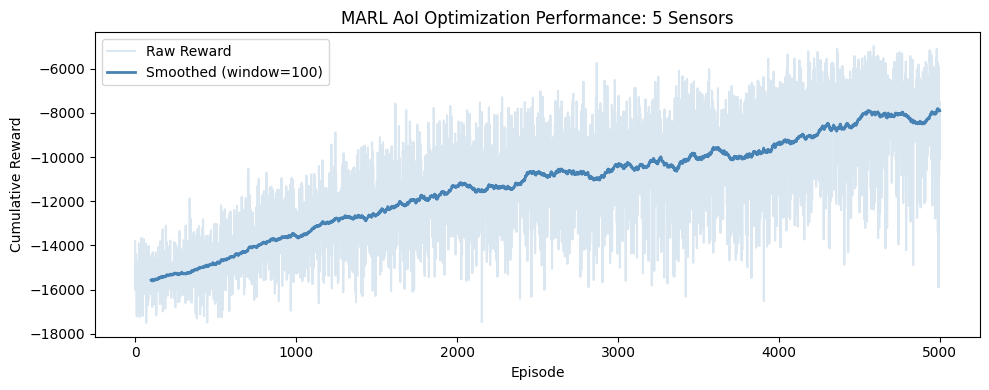

In [5]:
import matplotlib.pyplot as plt
import numpy as np

window = 100
raw = np.array(network.past_rewards)
smoothed = np.convolve(raw, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(raw, alpha=0.2, color='steelblue', label='Raw Reward')
plt.plot(range(window-1, len(raw)), smoothed, color='steelblue', linewidth=2, label=f'Smoothed (window={window})')
plt.title(f"MARL AoI Optimization Performance: {network.num_sensors} Sensors")
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward')
plt.legend()
plt.tight_layout()
plt.show()

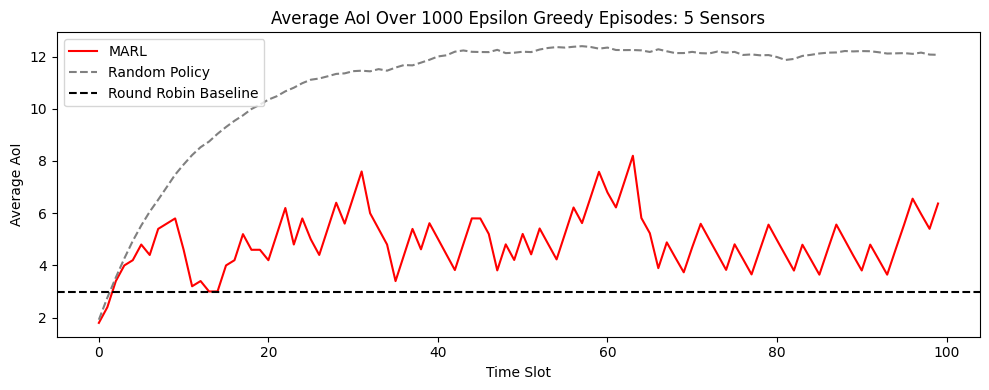

In [10]:
baseline = (NUM_SENSORS + 1) / 2

plt.figure(figsize=(10, 4))
plt.plot(avg_aoi,        label="MARL", color="red")
plt.plot(avg_aoi_random, label="Random Policy", color="grey", linestyle="--")
plt.axhline(y=baseline,  label="Round Robin Baseline", color="black", linestyle="--")

plt.title(f"Average AoI Over {num_eval_episodes} Epsilon Greedy Episodes: {network.num_sensors} Sensors")
plt.xlabel("Time Slot")
plt.ylabel("Average AoI")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
mean_aoi = sum(avg_aoi) / len(avg_aoi)
print(f"The mean is: {mean_aoi}")

The mean is: 4.905170000000007


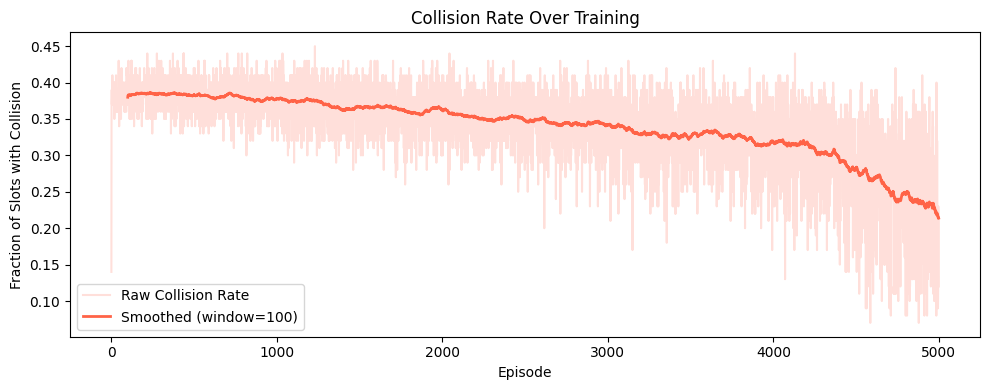

In [8]:
epsilon = epsilon_start
collision_rates = []

for it in range(num_episodes):
    episode_return = 0
    episode_collisions = 0

    for t in range(num_time_slots):
        actions = []
        for sensor in network.sensors:
            state = sensor.get_state()
            actions.append(sensor.choose_action(state, epsilon))

        step_reward = network.step(actions)
        episode_return += step_reward

        transmitting = [i for i, a in enumerate(actions) if a == TRANSMIT]
        if len(transmitting) > 1:
            episode_collisions += 1

    collision_rates.append(episode_collisions / num_time_slots)
    network.past_rewards.append(episode_return)
    epsilon *= epsilon_decay
    network.reset()

window = 100
smoothed_cr = np.convolve(collision_rates, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(collision_rates, alpha=0.2, color='tomato', label='Raw Collision Rate')
plt.plot(range(window-1, len(collision_rates)), smoothed_cr, color='tomato', linewidth=2, label=f'Smoothed (window={window})')
plt.title('Collision Rate Over Training')
plt.xlabel('Episode')
plt.ylabel('Fraction of Slots with Collision')
plt.legend()
plt.tight_layout()
plt.show()